In [10]:
import os
from dotenv import load_dotenv

load_dotenv()

True

# Data Agent


### STATE


In [11]:
from typing import TypedDict, Optional


class DataAgentState(TypedDict):
    symbol: str
    period: str

    current_price: Optional[float]
    open_price: Optional[float]
    high_52w: Optional[float]
    low_52w: Optional[float]
    volume: Optional[int]
    avg_volume: Optional[int]
    price_history: Optional[list[dict]]
    price_change_pct: Optional[float]

    market_cap: Optional[float]
    pe_ratio: Optional[float]
    eps: Optional[float]
    revenue: Optional[float]
    profit_margin: Optional[float]
    dividend_yield: Optional[float]
    beta: Optional[float]
    sector: Optional[str]
    industry: Optional[str]
    description: Optional[str]

    price_fetch_success: Optional[bool]
    fundamentals_fetch_success: Optional[bool]
    retry_count: Optional[int]
    errors: Optional[list[str]]

    data_ready: Optional[bool]
    summary: Optional[str]

In [12]:
test_state: DataAgentState = {
    "symbol": "AAPL",
    "period": "1y",
    "current_price": None,
    "open_price": None,
    "high_52w": None,
    "low_52w": None,
    "volume": None,
    "avg_volume": None,
    "price_history": None,
    "price_change_pct": None,
    "market_cap": None,
    "pe_ratio": None,
    "eps": None,
    "revenue": None,
    "profit_margin": None,
    "dividend_yield": None,
    "beta": None,
    "sector": None,
    "industry": None,
    "description": None,
    "price_fetch_success": None,
    "fundamentals_fetch_success": None,
    "retry_count": 0,
    "errors": [],
    "data_ready": None,
    "summary": None,
}

### Fetch price node


In [13]:
import yfinance as yf
from datetime import datetime


def fetch_price_node(state: DataAgentState) -> dict:
    symbol = state["symbol"]
    period = state["period"]
    errors = state["errors"]

    print(f"📈 Fetching price data for {symbol}...")

    try:
        ticker = yf.Ticker(symbol)
        info = ticker.info
        current_price = (
            info.get("currentPrice")
            or info.get("regularMarketPrice")
            or info.get("previousClose")
        )
        high_52w = info.get("fiftyTwoWeekHigh")
        low_52w = info.get("fiftyTwoWeekLow")
        volume = info.get("volume") or info.get("regularMarketVolume")
        avg_volume = info.get("averageVolume")
        open_price = info.get("open") or info.get("regularMarketOpen")
        hist = ticker.history(period=period)
        if hist.empty:
            raise ValueError(f"No price history found for {symbol}")

        price_history = [
            {
                "date": str(idx.date()),
                "open": round(row["Open"], 2),
                "high": round(row["High"], 2),
                "low": round(row["Low"], 2),
                "close": round(row["Close"], 2),
                "volume": int(row["Volume"]),
            }
            for idx, row in hist.iterrows()
        ]
        if len(price_history) >= 2:
            first_close = price_history[0]["close"]
            last_close = price_history[-1]["close"]
            price_change_pct = round(
                ((last_close - first_close) / first_close) * 100, 2
            )
        else:
            price_change_pct = 0.0

        print(f"✅ fetch_price_node → {symbol} @ ${current_price}")
        print(f"   52w High: ${high_52w} | 52w Low: ${low_52w}")
        print(f"   Price change ({period}): {price_change_pct}%")
        print(f"   History records: {len(price_history)}")

        return {
            "current_price": current_price,
            "open_price": open_price,
            "high_52w": high_52w,
            "low_52w": low_52w,
            "volume": volume,
            "avg_volume": avg_volume,
            "price_history": price_history,
            "price_change_pct": price_change_pct,
            "price_fetch_success": True,
            "errors": errors,
        }
    except Exception as e:
        error_msg = f"fetch_price_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "price_fetch_success": False,
            "errors": errors + [error_msg],
        }

### Fetch Fundamentals Node


In [14]:
import requests

ALPHA_VANTAGE_BASE = "https://www.alphavantage.co/query"


def safe_float(val):
    try:
        return float(val) if val and val != "None" else None
    except Exception:
        return None


def fetch_fundamentals_node(state: DataAgentState) -> dict:
    symbol = state["symbol"]
    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")
    errors = state.get("errors", [])

    print(f"📊 Fetching fundamentals for {symbol}...")

    try:
        response = requests.get(
            ALPHA_VANTAGE_BASE,
            params={"function": "OVERVIEW", "symbol": symbol, "apikey": api_key},
        )
        data = response.json()

        if "Note" in data:
            raise ValueError("Alpha Vantage rate limit hit — wait 1 minute")

        if not data or "Symbol" not in data:
            raise ValueError(f"No fundamental data found for {symbol}")

        market_cap = safe_float(data.get("MarketCapitalization"))
        pe_ratio = safe_float(data.get("PERatio"))
        eps = safe_float(data.get("EPS"))
        revenue = safe_float(data.get("RevenueTTM"))
        profit_margin = safe_float(data.get("ProfitMargin"))
        dividend_yield = safe_float(data.get("DividendYield"))
        beta = safe_float(data.get("Beta"))
        sector = data.get("Sector")
        industry = data.get("Industry")
        description = data.get("Description", "")

        print(f"✅ fetch_fundamentals_node → {symbol}")
        print(
            f"   Market Cap:    ${market_cap:,.0f}"
            if market_cap
            else "   Market Cap: N/A"
        )
        print(f"   P/E Ratio:     {pe_ratio}")
        print(f"   EPS:           {eps}")
        print(f"   Profit Margin: {profit_margin}")
        print(f"   Sector:        {sector}")
        print(f"   Industry:      {industry}")

        return {
            "market_cap": market_cap,
            "pe_ratio": pe_ratio,
            "eps": eps,
            "revenue": revenue,
            "profit_margin": profit_margin,
            "dividend_yield": dividend_yield,
            "beta": beta,
            "sector": sector,
            "industry": industry,
            "description": description,
            "fundamentals_fetch_success": True,
            "errors": errors,
        }
    except Exception as e:
        error_msg = f"fetch_fundamentals_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "fundamentals_fetch_success": False,
            "errors": errors + [error_msg],
        }


### Validate Node


In [15]:
MAX_RETRIES = 2


def validate_node(state: DataAgentState) -> dict:
    price_ok = state.get("price_fetch_success", False)
    fundamentals_ok = state.get("fundamentals_fetch_success", False)
    retry_count = state.get("retry_count", 0)
    errors = state.get("errors", [])
    symbol = state["symbol"]

    print(f"🔍 Validating data for {symbol}...")
    print(f"   Price fetch:        {'✅' if price_ok else '❌'}")
    print(f"   Fundamentals fetch: {'✅' if fundamentals_ok else '❌'}")
    print(f"   Retry count:        {retry_count}/{MAX_RETRIES}")

    if price_ok and fundamentals_ok:
        print("✅ validate_node → All data valid, proceeding")
        return {
            "data_ready": True,
            "retry_count": retry_count,
            "errors": errors,
        }

    if retry_count < MAX_RETRIES:
        print(
            f"⚠️  validate_node → Incomplete data, retrying ({retry_count + 1}/{MAX_RETRIES})"
        )
        return {
            "data_ready": False,
            "retry_count": retry_count + 1,
            "errors": errors,
        }

    print("⚠️  validate_node → Max retries hit, proceeding with partial data")
    return {
        "data_ready": True,
        "retry_count": retry_count,
        "errors": errors + [f"Max retries hit for {symbol} — partial data"],
    }

### Summary Node


In [16]:
from groq import Groq

groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

In [17]:
def summary_node(state: DataAgentState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])

    print(f"📝 Generating data summary for {symbol}...")
    price_section = (
        f"""
        PRICE DATA ({symbol}):
        - Current Price:    ${state.get("current_price", "N/A")}
        - 52-Week High:     ${state.get("high_52w", "N/A")}
        - 52-Week Low:      ${state.get("low_52w", "N/A")}
        - Price Change:     {state.get("price_change_pct", "N/A")}% over {state.get("period", "1y")}
        - Volume:           {state.get("volume", "N/A"):,} (Avg: {state.get("avg_volume", "N/A"):,})
        """
        if state.get("price_fetch_success")
        else "PRICE DATA: Unavailable"
    )

    fundamentals_section = (
        f"""
        FUNDAMENTALS ({symbol}):
        - Market Cap:       ${state.get("market_cap", 0):,.0f}
        - P/E Ratio:        {state.get("pe_ratio", "N/A")}
        - EPS:              {state.get("eps", "N/A")}
        - Revenue (TTM):    ${state.get("revenue", 0):,.0f}
        - Profit Margin:    {state.get("profit_margin", "N/A")}
        - Dividend Yield:   {state.get("dividend_yield", "N/A")}
        - Beta:             {state.get("beta", "N/A")}
        - Sector:           {state.get("sector", "N/A")}
        - Industry:         {state.get("industry", "N/A")}
        """
        if state.get("fundamentals_fetch_success")
        else "FUNDAMENTALS: Unavailable"
    )

    prompt = f"""
    You are a financial data analyst. Based on the following raw data,
    write a concise 3-4 sentence factual summary of {symbol}'s current
    financial position. No recommendations — just facts.

    {price_section}
    {fundamentals_section}
    """

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
        )
        summary = response.choices[0].message.content.strip()
        print("✅ summary_node → Summary generated")
        print("\n── Summary ──────────────────────────────")
        print(summary)

        return {"summary": summary, "errors": errors}

    except Exception as e:
        error_msg = f"summary_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "summary": f"Summary unavailable for {symbol}",
            "errors": errors + [error_msg],
        }

### Graph Setup


In [18]:
from langgraph.graph import StateGraph, END


def should_retry(state: DataAgentState) -> str:
    if not state.get("data_ready") and state.get("retry_count", 0) < MAX_RETRIES:
        return "fetch_price_node"
    return "summary_node"

In [19]:
def build_data_agent() -> any:
    graph = StateGraph(DataAgentState)

    graph.add_node("fetch_price_node", fetch_price_node)
    graph.add_node("fetch_fundamentals_node", fetch_fundamentals_node)
    graph.add_node("validate_node", validate_node)
    graph.add_node("summary_node", summary_node)

    graph.set_entry_point("fetch_price_node")

    graph.add_edge("fetch_price_node", "fetch_fundamentals_node")
    graph.add_edge("fetch_fundamentals_node", "validate_node")

    graph.add_conditional_edges(
        "validate_node",
        should_retry,
        {
            "fetch_price_node": "fetch_price_node",
            "summary_node": "summary_node",
        },
    )

    graph.add_edge("summary_node", END)

    return graph.compile()

In [20]:
data_agent = build_data_agent()

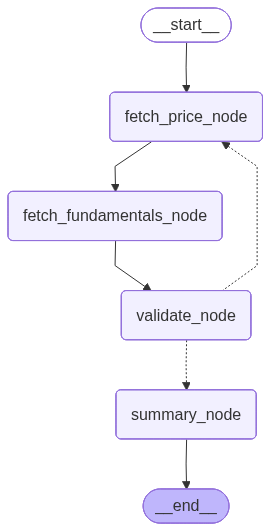

In [21]:
from IPython.display import Image, display

display(Image(data_agent.get_graph().draw_mermaid_png()))

# Analysis Agent


In [22]:
from typing import TypedDict, Optional, Literal


class AnalysisAgentState(TypedDict):
    symbol: str
    current_price: Optional[float]
    high_52w: Optional[float]
    low_52w: Optional[float]
    price_change_pct: Optional[float]
    price_history: Optional[list[dict]]
    pe_ratio: Optional[float]
    eps: Optional[float]
    market_cap: Optional[float]
    revenue: Optional[float]
    profit_margin: Optional[float]
    beta: Optional[float]
    dividend_yield: Optional[float]
    sector: Optional[str]
    data_summary: Optional[str]

    sma_20: Optional[float]
    sma_50: Optional[float]
    sma_200: Optional[float]
    rsi: Optional[float]
    macd: Optional[float]
    macd_signal: Optional[float]
    volatility: Optional[float]

    price_vs_52w_high: Optional[float]
    price_vs_52w_low: Optional[float]
    golden_cross: Optional[bool]
    death_cross: Optional[bool]

    pe_signal: Optional[str]
    margin_signal: Optional[str]
    momentum_signal: Optional[str]

    risk_score: Optional[float]
    risk_label: Optional[str]
    recommendation: Optional[
        Literal["strong_buy", "buy", "hold", "sell", "strong_sell"]
    ]
    reasoning: Optional[str]

    errors: Optional[list[str]]

### Technical Node


In [23]:
import numpy as np
import pandas as pd

In [24]:
def technical_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    price_history = state.get("price_history", [])
    current_price = state.get("current_price")
    high_52w = state.get("high_52w")
    low_52w = state.get("low_52w")
    errors = state.get("errors", [])

    print(f"📐 Calculating technical indicators for {symbol}...")

    if not price_history or len(price_history) < 20:
        error_msg = f"Insufficient price history for {symbol}"
        print(f"❌ {error_msg}")
        return {"errors": errors + [error_msg]}

    df = pd.DataFrame(price_history)
    closes = df["close"].astype(float)

    sma_20 = round(closes.tail(20).mean(), 2)
    sma_50 = round(closes.tail(50).mean(), 2) if len(closes) >= 50 else None
    sma_200 = round(closes.tail(200).mean(), 2) if len(closes) >= 200 else None

    delta = closes.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.tail(14).mean()
    avg_loss = loss.tail(14).mean()
    rs = avg_gain / avg_loss if avg_loss != 0 else 0
    rsi = round(100 - (100 / (1 + rs)), 2)

    ema_12 = closes.ewm(span=12, adjust=False).mean()
    ema_26 = closes.ewm(span=26, adjust=False).mean()
    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    macd = round(macd_line.iloc[-1], 4)
    macd_signal = round(signal_line.iloc[-1], 4)

    daily_returns = closes.pct_change().dropna()
    volatility = round(daily_returns.std() * np.sqrt(252) * 100, 2)

    price_vs_52w_high = (
        round(((current_price - high_52w) / high_52w) * 100, 2) if high_52w else None
    )
    price_vs_52w_low = (
        round(((current_price - low_52w) / low_52w) * 100, 2) if low_52w else None
    )

    golden_cross = bool(sma_20 > sma_50) if sma_50 else None
    death_cross = bool(sma_20 < sma_50) if sma_50 else None

    print(f"✅ technical_node → {symbol}")
    print(f"   SMA20:  ${sma_20} | SMA50: ${sma_50} | SMA200: ${sma_200}")
    print(f"   RSI:    {rsi}")
    print(f"   MACD:   {macd} | Signal: {macd_signal}")
    print(f"   Volatility: {volatility}%")
    print(f"   vs 52w High: {price_vs_52w_high}% | vs 52w Low: +{price_vs_52w_low}%")
    print(f"   Golden Cross: {golden_cross} | Death Cross: {death_cross}")

    return {
        "sma_20": sma_20,
        "sma_50": sma_50,
        "sma_200": sma_200,
        "rsi": rsi,
        "macd": macd,
        "macd_signal": macd_signal,
        "volatility": volatility,
        "price_vs_52w_high": price_vs_52w_high,
        "price_vs_52w_low": price_vs_52w_low,
        "golden_cross": golden_cross,
        "death_cross": death_cross,
        "errors": errors,
    }

### Valuation Node


In [25]:
def valuation_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    pe_ratio = state.get("pe_ratio")
    profit_margin = state.get("profit_margin")
    price_change = state.get("price_change_pct")
    rsi = state.get("rsi")
    macd = state.get("macd")
    macd_signal = state.get("macd_signal")
    errors = state.get("errors", [])

    print(f"💰 Calculating valuation signals for {symbol}...")

    if pe_ratio is None:
        pe_signal = "unknown"
    elif pe_ratio < 15:
        pe_signal = "undervalued"
    elif pe_ratio < 25:
        pe_signal = "fair"
    elif pe_ratio < 40:
        pe_signal = "slightly_overvalued"
    else:
        pe_signal = "overvalued"

    if profit_margin is None:
        margin_signal = "unknown"
    elif profit_margin >= 0.30:
        margin_signal = "strong"
    elif profit_margin >= 0.15:
        margin_signal = "moderate"
    elif profit_margin >= 0.05:
        margin_signal = "weak"
    else:
        margin_signal = "negative"

    bullish_signals = 0
    bearish_signals = 0

    if price_change and price_change > 10:
        bullish_signals += 1
    elif price_change and price_change < -10:
        bearish_signals += 1

    if rsi:
        if rsi < 30:
            bullish_signals += 1
        elif rsi > 70:
            bearish_signals += 1

    if macd and macd_signal:
        if macd > macd_signal:
            bullish_signals += 1
        else:
            bearish_signals += 1

    if bullish_signals > bearish_signals:
        momentum_signal = "bullish"
    elif bearish_signals > bullish_signals:
        momentum_signal = "bearish"
    else:
        momentum_signal = "neutral"

    print(f"✅ valuation_node → {symbol}")
    print(f"   P/E Signal:      {pe_signal} (P/E: {pe_ratio})")
    print(f"   Margin Signal:   {margin_signal} (margin: {profit_margin})")
    print(f"   Momentum Signal: {momentum_signal}")
    print(f"   Bullish: {bullish_signals} | Bearish: {bearish_signals}")

    return {
        "pe_signal": pe_signal,
        "margin_signal": margin_signal,
        "momentum_signal": momentum_signal,
        "errors": errors,
    }

### Risk Node


In [26]:
def risk_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    beta = state.get("beta")
    volatility = state.get("volatility")
    rsi = state.get("rsi")
    pe_signal = state.get("pe_signal")
    price_vs_52w_high = state.get("price_vs_52w_high")
    momentum_signal = state.get("momentum_signal")
    errors = state.get("errors", [])

    print(f"⚠️  Calculating risk score for {symbol}...")

    risk_score = 5.0

    if beta:
        if beta > 1.5:
            risk_score += 1.5
        elif beta > 1.2:
            risk_score += 0.8
        elif beta < 0.8:
            risk_score -= 0.5

    if volatility:
        if volatility > 40:
            risk_score += 1.5
        elif volatility > 25:
            risk_score += 0.8
        elif volatility < 15:
            risk_score -= 0.5

    if rsi:
        if rsi > 75:
            risk_score += 1.0
        elif rsi < 25:
            risk_score += 0.5
        elif 40 <= rsi <= 60:
            risk_score -= 0.5

    if pe_signal == "overvalued":
        risk_score += 1.0
    elif pe_signal == "undervalued":
        risk_score -= 0.5

    if price_vs_52w_high:
        if price_vs_52w_high > -5:
            risk_score += 0.5
        elif price_vs_52w_high < -30:
            risk_score += 1.0

    if momentum_signal == "bearish":
        risk_score += 0.5
    elif momentum_signal == "bullish":
        risk_score -= 0.5

    risk_score = round(max(0.0, min(10.0, risk_score)), 2)

    if risk_score <= 3.5:
        risk_label = "low"
    elif risk_score <= 6.5:
        risk_label = "medium"
    else:
        risk_label = "high"

    print(f"✅ risk_node → {symbol}")
    print(f"   Risk Score: {risk_score}/10")
    print(f"   Risk Label: {risk_label}")

    return {
        "risk_score": risk_score,
        "risk_label": risk_label,
        "errors": errors,
    }


### Recommendation Node


In [27]:
RECOMMENDATION_PROMPT = """
You are a senior financial analyst. Based on the following analysis data,
provide a stock recommendation and detailed reasoning.

You MUST respond ONLY with valid JSON in this exact format:
{{
    "recommendation": "buy",
    "reasoning": "3-4 sentence explanation"
}}

Valid recommendation values: "strong_buy", "buy", "hold", "sell", "strong_sell"

Rules:
- Base recommendation strictly on the data provided
- No personal opinions — only data-driven conclusions
- reasoning must reference specific metrics from the data
- Never recommend based on company name or brand

Analysis Data:
{data}
"""

In [28]:
import json
import re


def recommendation_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])

    print(f"🤖 Generating recommendation for {symbol}...")

    analysis_data = f"""
        Symbol:           {symbol}
        Current Price:    ${state.get("current_price")}
        Price Change 1Y:  {state.get("price_change_pct")}%
        52w High:         ${state.get("high_52w")}
        52w Low:          ${state.get("low_52w")}
        vs 52w High:      {state.get("price_vs_52w_high")}%
        vs 52w Low:       +{state.get("price_vs_52w_low")}%

        Technical:
        - SMA 20:         ${state.get("sma_20")}
        - SMA 50:         ${state.get("sma_50")}
        - SMA 200:        ${state.get("sma_200")}
        - RSI:            {state.get("rsi")}
        - MACD:           {state.get("macd")}
        - MACD Signal:    {state.get("macd_signal")}
        - Volatility:     {state.get("volatility")}%
        - Golden Cross:   {state.get("golden_cross")}
        - Death Cross:    {state.get("death_cross")}

        Valuation:
        - P/E Ratio:      {state.get("pe_ratio")}
        - P/E Signal:     {state.get("pe_signal")}
        - EPS:            {state.get("eps")}
        - Profit Margin:  {state.get("profit_margin")}
        - Margin Signal:  {state.get("margin_signal")}
        - Momentum:       {state.get("momentum_signal")}

        Risk:
        - Beta:           {state.get("beta")}
        - Risk Score:     {state.get("risk_score")}/10
        - Risk Label:     {state.get("risk_label")}
        - Sector:         {state.get("sector")}

        Data Summary:
        {state.get("data_summary")}
    """

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {
                    "role": "user",
                    "content": RECOMMENDATION_PROMPT.format(data=analysis_data),
                }
            ],
            temperature=0.1,
        )

        raw = response.choices[0].message.content.strip()
        try:
            result = json.loads(raw)
        except json.JSONDecodeError:
            match = re.search(r"\{.*\}", raw, re.DOTALL)
            result = json.loads(match.group()) if match else {}
        recommendation = result.get("recommendation", "hold")
        reasoning = result.get("reasoning", "")

        print(f"✅ recommendation_node → {symbol}")
        print(f"   Recommendation: {recommendation.upper()}")
        print(f"   Reasoning: {reasoning}")

        return {
            "recommendation": recommendation,
            "reasoning": reasoning,
            "errors": errors,
        }

    except Exception as e:
        error_msg = f"recommendation_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "recommendation": "hold",
            "reasoning": "Unable to generate recommendation",
            "errors": errors + [error_msg],
        }


### GRAPH


In [29]:
def build_analysis_agent():
    graph = StateGraph(AnalysisAgentState)

    graph.add_node("technical_node", technical_node)
    graph.add_node("valuation_node", valuation_node)
    graph.add_node("risk_node", risk_node)
    graph.add_node("recommendation_node", recommendation_node)

    graph.set_entry_point("technical_node")

    graph.add_edge("technical_node", "valuation_node")
    graph.add_edge("valuation_node", "risk_node")
    graph.add_edge("risk_node", "recommendation_node")
    graph.add_edge("recommendation_node", END)

    return graph.compile()


analysis_agent = build_analysis_agent()


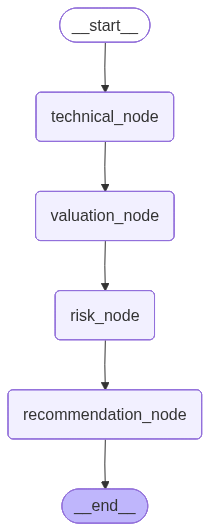

In [30]:
display(Image(analysis_agent.get_graph().draw_mermaid_png()))

In [31]:
symbols = ["AAPL"]

for symbol in symbols:
    print(f"\n{'=' * 60}")
    print(f"Running Analysis Agent for: {symbol}")
    print("=" * 60)

    raw_data = data_agent.invoke(
        {"symbol": symbol, "period": "1y", "retry_count": 0, "errors": []}
    )

    analysis_input: AnalysisAgentState = {
        "symbol": raw_data["symbol"],
        "current_price": raw_data["current_price"],
        "high_52w": raw_data["high_52w"],
        "low_52w": raw_data["low_52w"],
        "price_change_pct": raw_data["price_change_pct"],
        "price_history": raw_data["price_history"],
        "pe_ratio": raw_data["pe_ratio"],
        "eps": raw_data["eps"],
        "market_cap": raw_data["market_cap"],
        "revenue": raw_data["revenue"],
        "profit_margin": raw_data["profit_margin"],
        "beta": raw_data["beta"],
        "dividend_yield": raw_data["dividend_yield"],
        "sector": raw_data["sector"],
        "data_summary": raw_data["summary"],
        "errors": [],
    }

    result = analysis_agent.invoke(analysis_input)

    print("\n── Final Output ─────────────────────────────")
    print(f"Symbol:         {result['symbol']}")
    print(f"RSI:            {result.get('rsi')}")
    print(f"Golden Cross:   {result.get('golden_cross')}")
    print(f"P/E Signal:     {result.get('pe_signal')}")
    print(f"Momentum:       {result.get('momentum_signal')}")
    print(f"Risk Score:     {result.get('risk_score')}/10")
    print(f"Risk Label:     {result.get('risk_label')}")
    print(f"Recommendation: {result.get('recommendation', '').upper()}")
    print(f"Reasoning:      {result.get('reasoning')}")
    print(f"Errors:         {result.get('errors')}")


Running Analysis Agent for: AAPL
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
✅ fetch_fundamentals_node → AAPL
   Market Cap:    $4,376,979,046,000
   P/E Ratio:     36.12
   EPS:           8.25
   Profit Margin: 0.272
   Sector:        TECHNOLOGY
   Industry:      CONSUMER ELECTRONICS
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ✅
   Retry count:        0/2
✅ validate_node → All data valid, proceeding
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL's current market capitalization stands at approximately $4.38 trillion, with a price-to-earnings ratio of 36.12 and earnings per share of $8.25. The company has generated $451.44 billion in revenue over the trailing 12 months, with a profit margin of 27.2%. AAPL's stock price has incre

# RAG Agent


In [32]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_astradb import AstraDBVectorStore

d:\ai-learning\finsight-ai\agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1456.57it/s]


In [34]:
vector_store = AstraDBVectorStore(
    embedding=embeddings,
    collection_name=os.getenv("ASTRA_DB_COLLECTION"),
    token=os.getenv("ASTRA_DB_APPLICATION_TOKEN"),
    api_endpoint=os.getenv("ASTRA_DB_API_ENDPOINT"),
    metric="cosine",
)

In [35]:
class RAGAgentState(TypedDict):
    symbol: str
    mode: Literal["ingest", "query"]
    file_path: Optional[str]
    question: Optional[str]

    chunks: Optional[list[str]]
    sources: Optional[list[dict]]
    chunks_stored: Optional[int]

    retrieved_docs: Optional[list[str]]
    retrieved_sources: Optional[list[dict]]
    answer: Optional[str]

    errors: Optional[list[str]]


In [36]:
ingest_test_state: RAGAgentState = {
    "symbol": "AAPL",
    "mode": "ingest",
    "errors": [],
}

query_test_state: RAGAgentState = {
    "symbol": "AAPL",
    "mode": "query",
    "question": "What are the main risk factors for AAPL?",
    "errors": [],
}

### Route Node


In [37]:
def route_node(state: RAGAgentState) -> dict:
    mode = state.get("mode")
    symbol = state["symbol"]
    print(f"🔀 route_node → {symbol} | mode: {mode}")
    return {}

### Ingest Node


In [38]:
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\Prashant\AppData\Local\Temp\ipykernel_4376\3381221475.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


In [39]:
def ingest_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    file_path = state.get("file_path")
    errors = state.get("errors", [])

    if not file_path:
        error = "No file_path provided for ingest"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

    print(f"📄 Ingesting document for {symbol}: {file_path}")

    try:
        ext = Path(file_path).suffix.lower()
        if ext == ".pdf":
            loader = PyPDFLoader(file_path)
        elif ext == ".txt":
            loader = TextLoader(file_path)
        else:
            raise ValueError(f"Unsupported file type: {ext}")

        docs = loader.load()
        print(f"   Loaded {len(docs)} page(s)")

        splitter = RecursiveCharacterTextSplitter(
            chunk_size=512,
            chunk_overlap=64,
            separators=["\n\n", "\n", ".", " "],
        )
        split_docs = splitter.split_documents(docs)
        print(f"   Split into {len(split_docs)} chunks")

        chunks = [doc.page_content for doc in split_docs]
        sources = [
            {
                "symbol": symbol,
                "filename": Path(file_path).name,
                "page": doc.metadata.get("page", 0),
                "chunk_index": i,
                "char_count": len(doc.page_content),
            }
            for i, doc in enumerate(split_docs)
        ]

        print(f"✅ ingest_node → {len(chunks)} chunks ready for {symbol}")
        return {
            "chunks": chunks,
            "sources": sources,
            "errors": errors,
        }

    except Exception as e:
        error = f"ingest_node error: {str(e)}"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

### Embed Node


In [40]:
from langchain_core.documents import Document

In [41]:
def embed_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    chunks = state.get("chunks", [])
    sources = state.get("sources", [])
    errors = state.get("errors", [])

    if not chunks:
        error = "No chunks to embed"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

    print(f"⏳ Embedding {len(chunks)} chunks for {symbol}...")

    documents = [
        Document(
            page_content=chunk,
            metadata=sources[i] if i < len(sources) else {"symbol": symbol},
        )
        for i, chunk in enumerate(chunks)
    ]

    inserted_ids = vector_store.add_documents(documents)

    print(f"✅ embed_node → {len(inserted_ids)} chunks upserted for {symbol}")
    return {
        "chunks_stored": len(inserted_ids),
        "errors": errors,
    }

### Retrieve Node


In [42]:
SIMILARITY_THRESHOLD = 0.65

In [43]:
def retrieve_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    question = state.get("question")
    errors = state.get("errors", [])

    if not question:
        error = "No question provided for retrieval"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

    print(f"🔍 Retrieving docs for {symbol}: '{question}'")

    results = vector_store.similarity_search_with_score(
        query=question,
        k=4,
        filter={"symbol": symbol},
    )

    if not results:
        print(f"⚠️  No results found for {symbol}")
        return {
            "retrieved_docs": [],
            "retrieved_sources": [],
            "errors": errors,
        }

    retrieved_docs = []
    retrieved_sources = []

    for doc, score in results:
        if score >= SIMILARITY_THRESHOLD:
            retrieved_docs.append(doc.page_content)
            retrieved_sources.append(
                {
                    **doc.metadata,
                    "similarity_score": round(score, 4),
                }
            )
            print(f"   Score: {round(score, 4)} | {doc.page_content[:80]}...")
        else:
            print(f"   ⚠️ Discarded (score: {round(score, 4)}) — below threshold")

    print(f"✅ retrieve_node → {len(retrieved_docs)} relevant chunks for {symbol}")
    return {
        "retrieved_docs": retrieved_docs,
        "retrieved_sources": retrieved_sources,
        "errors": errors,
    }

### Answer Node


In [44]:
RAG_SYSTEM_PROMPT = """
You are FinSight, an AI financial analyst assistant.
Answer the user's question strictly based on the provided document context.

Rules:
1. Answer ONLY from the provided context
2. If context is insufficient say: "I don't have enough information in the uploaded documents to answer this."
3. Always cite the source filename and page number
4. Be concise and precise — financial accuracy matters
5. Never speculate beyond what the documents say
"""


In [45]:
def answer_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    question = state.get("question")
    retrieved_docs = state.get("retrieved_docs", [])
    sources = state.get("retrieved_sources", [])
    errors = state.get("errors", [])

    print(f"💬 Generating answer for {symbol}: '{question}'")

    if not retrieved_docs:
        answer = (
            "I don't have enough information in the uploaded "
            f"documents to answer this question about {symbol}."
        )
        print("⚠️  No retrieved docs — returning default answer")
        return {"answer": answer, "errors": errors}

    context = "\n\n---\n\n".join(
        [
            f"[Source: {src.get('filename', 'unknown')}, Page {src.get('page', 0)}]\n{doc}"
            for doc, src in zip(retrieved_docs, sources)
        ]
    )

    prompt = f"""
    Context from {symbol} financial documents:

    {context}

    Question: {question}

    Answer based strictly on the context above.
    """

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": RAG_SYSTEM_PROMPT},
                {"role": "user", "content": prompt},
            ],
            temperature=0.1,
        )
        answer = response.choices[0].message.content.strip()
        print(f"✅ answer_node → Answer generated for {symbol}")
        print("\n── Answer ───────────────────────────────")
        print(answer)
        return {"answer": answer, "errors": errors}

    except Exception as e:
        error = f"answer_node error: {str(e)}"
        print(f"❌ {error}")
        return {
            "answer": "Unable to generate answer due to an error.",
            "errors": errors + [error],
        }

### GRAPH


In [46]:
def route_by_mode(state: RAGAgentState) -> str:
    mode = state.get("mode")
    if mode == "ingest":
        return "ingest_node"
    return "retrieve_node"

In [47]:
def build_rag_agent():
    graph = StateGraph(RAGAgentState)

    graph.add_node("route_node", route_node)
    graph.add_node("ingest_node", ingest_node)
    graph.add_node("embed_node", embed_node)
    graph.add_node("retrieve_node", retrieve_node)
    graph.add_node("answer_node", answer_node)

    graph.set_entry_point("route_node")

    graph.add_conditional_edges(
        "route_node",
        route_by_mode,
        {
            "ingest_node": "ingest_node",
            "retrieve_node": "retrieve_node",
        },
    )

    graph.add_edge("ingest_node", "embed_node")
    graph.add_edge("embed_node", END)

    graph.add_edge("retrieve_node", "answer_node")
    graph.add_edge("answer_node", END)

    return graph.compile()


In [48]:
rag_agent = build_rag_agent()


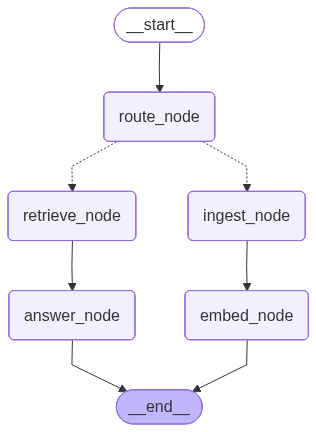

In [49]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [50]:
# create a fake AAPL annual report excerpt for testing
test_doc_path = Path.cwd() / "aapl_annual_report.txt"

test_doc_path.write_text("""
APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Conditions
Apple's business is subject to risks from global economic conditions including
inflation, interest rate changes, and currency fluctuations. A downturn in 
consumer spending could adversely affect iPhone and Mac sales.

2. Supply Chain Concentration
Apple relies heavily on suppliers in Asia, particularly Taiwan and China.
Geopolitical tensions or natural disasters could disrupt production significantly.
The company has been diversifying manufacturing to India and Vietnam.

3. Competition
Apple faces intense competition from Samsung, Google, and Chinese manufacturers
in the smartphone market. The services segment faces competition from Spotify,
Netflix, and other digital content providers.

4. Regulatory Risk
Apple faces ongoing antitrust investigations in the EU and US regarding the
App Store policies and fees. The Digital Markets Act in Europe may require
significant changes to Apple's business practices.

FINANCIAL HIGHLIGHTS 2024

Revenue:          $451.4 billion (up 2% YoY)
Net Income:       $122.7 billion (up 4% YoY)
Gross Margin:     46.2%
Services Revenue: $96.2 billion (up 13% YoY)
iPhone Revenue:   $201.2 billion (down 1% YoY)
Cash Position:    $162.1 billion

BUSINESS SEGMENTS

iPhone accounted for 44.6% of total revenue.
Services grew to 21.3% of revenue — highest ever.
Mac revenue was $29.4 billion, up 7% YoY.
iPad revenue was $26.7 billion, down 6% YoY.
Wearables revenue was $37.0 billion, down 3% YoY.

OUTLOOK

Management expects continued growth in Services segment.
AI features (Apple Intelligence) launching across product line.
Vision Pro spatial computing platform in early adoption phase.
Capital return program: $110 billion buyback authorized.
""")

print(f"✅ Test document created: {test_doc_path}")

✅ Test document created: d:\ai-learning\finsight-ai\agent\notebooks\aapl_annual_report.txt


In [51]:
ingest_result = rag_agent.invoke(
    {
        "symbol": "AAPL",
        "mode": "ingest",
        "file_path": str(test_doc_path),
        "errors": [],
    }
)

print("\n── Ingest Result ────────────────────────────")
print(f"Chunks stored: {ingest_result.get('chunks_stored')}")
print(f"Errors:        {ingest_result.get('errors')}")

🔀 route_node → AAPL | mode: ingest
📄 Ingesting document for AAPL: d:\ai-learning\finsight-ai\agent\notebooks\aapl_annual_report.txt
   Loaded 1 page(s)
   Split into 4 chunks
✅ ingest_node → 4 chunks ready for AAPL
⏳ Embedding 4 chunks for AAPL...
✅ embed_node → 4 chunks upserted for AAPL

── Ingest Result ────────────────────────────
Chunks stored: 4
Errors:        []


In [52]:
test_questions = [
    "What are the main risk factors for AAPL?",
    "What was Apple's revenue in 2024?",
    "How is Apple's services segment performing?",
    "What is Apple's cash position?",
]

for question in test_questions:
    print(f"\n{'=' * 60}")
    print(f"Question: {question}")
    print("=" * 60)

    query_result = rag_agent.invoke(
        {
            "symbol": "AAPL",
            "mode": "query",
            "question": question,
            "errors": [],
        }
    )

    print(f"\nAnswer:\n{query_result.get('answer')}")
    print(f"Errors: {query_result.get('errors')}")


Question: What are the main risk factors for AAPL?
🔀 route_node → AAPL | mode: query
🔍 Retrieving docs for AAPL: 'What are the main risk factors for AAPL?'
   Score: 0.7459 | APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Condit...
   Score: 0.7459 | APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Condit...
   ⚠️ Discarded (score: 0.6238) — below threshold
   ⚠️ Discarded (score: 0.6238) — below threshold
✅ retrieve_node → 2 relevant chunks for AAPL
💬 Generating answer for AAPL: 'What are the main risk factors for AAPL?'
✅ answer_node → Answer generated for AAPL

── Answer ───────────────────────────────
According to the provided context, the main risk factor for AAPL is global economic conditions, which includes inflation, interest rate changes, and currency fluctuations, as it may lead to a downturn in consumer spending and adversely affect iPhone and Mac sales. [Source: aapl_annual_report.txt, Page 0]

Answer:
According to the pr

# Report Agent


In [53]:
class ReportAgentState(TypedDict):
    symbol: str

    current_price: Optional[float]
    price_change_pct: Optional[float]
    market_cap: Optional[float]
    pe_ratio: Optional[float]
    eps: Optional[float]
    revenue: Optional[float]
    profit_margin: Optional[float]
    beta: Optional[float]
    sector: Optional[str]
    industry: Optional[str]
    data_summary: Optional[str]

    sma_20: Optional[float]
    sma_50: Optional[float]
    rsi: Optional[float]
    macd: Optional[float]
    volatility: Optional[float]
    golden_cross: Optional[bool]
    pe_signal: Optional[str]
    margin_signal: Optional[str]
    momentum_signal: Optional[str]
    risk_score: Optional[float]
    risk_label: Optional[str]
    recommendation: Optional[str]
    reasoning: Optional[str]

    rag_context: Optional[str]  # relevant doc excerpts

    executive_summary: Optional[str]
    financial_analysis: Optional[str]
    technical_analysis: Optional[str]
    risk_assessment: Optional[str]
    recommendation_section: Optional[str]

    full_report: Optional[str]
    report_id: Optional[str]
    generated_at: Optional[str]

    errors: Optional[list[str]]

### Gather Node


In [54]:
def gather_node(state: ReportAgentState) -> dict:
    symbol = state["symbol"]
    print(f"📦 Gathering all inputs for {symbol} report...")

    missing = []
    if not state.get("data_summary"):
        missing.append("data_summary")
    if not state.get("recommendation"):
        missing.append("recommendation")
    if not state.get("risk_score"):
        missing.append("risk_score")

    if missing:
        print(f"⚠️  Missing inputs: {missing} — report will be partial")
    else:
        print(f"✅ gather_node → All inputs present for {symbol}")

    return {}

### Draft Node


In [55]:
from groq import Groq

groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

REPORT_SYSTEM_PROMPT = """
You are a senior equity research analyst at a top investment bank.
Generate a professional investment research report section.
Be precise, data-driven, and use financial terminology correctly.
Never speculate beyond the data provided.
"""


def draft_section(prompt: str) -> str:
    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": REPORT_SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ],
        temperature=0.2,
        max_tokens=500,
    )
    return response.choices[0].message.content.strip()


def draft_node(state: ReportAgentState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])

    print(f"✍️  Drafting report sections for {symbol}...")

    try:
        print("   Drafting executive summary...")
        exec_prompt = f"""
        Write a 3-4 sentence executive summary for {symbol}.

        Data:
        - Current Price: ${state.get("current_price")}
        - 1Y Price Change: {state.get("price_change_pct")}%
        - Market Cap: ${state.get("market_cap", 0):,.0f}
        - Sector: {state.get("sector")}
        - Recommendation: {state.get("recommendation", "").upper()}
        - Risk Label: {state.get("risk_label")}

        Data Summary: {state.get("data_summary")}
        """
        executive_summary = draft_section(exec_prompt)

        print("   Drafting financial analysis...")
        fin_prompt = f"""
        Write a financial analysis paragraph for {symbol}.

        Metrics:
        - Revenue: ${state.get("revenue", 0):,.0f}
        - EPS: {state.get("eps")}
        - P/E Ratio: {state.get("pe_ratio")} ({state.get("pe_signal")})
        - Profit Margin: {state.get("profit_margin")} ({state.get("margin_signal")})
        - Dividend Yield: {state.get("beta")}
        - Beta: {state.get("beta")}

        RAG Context (from annual report):
        {state.get("rag_context", "No document context available.")}

        Focus on valuation, profitability, and growth metrics.
        """
        financial_analysis = draft_section(fin_prompt)

        print("   Drafting technical analysis...")
        tech_prompt = f"""
        Write a technical analysis paragraph for {symbol}.

        Indicators:
        - SMA 20: ${state.get("sma_20")} | SMA 50: ${state.get("sma_50")}
        - RSI: {state.get("rsi")}
        - MACD: {state.get("macd")} | Signal: N/A
        - Volatility: {state.get("volatility")}%
        - Golden Cross: {state.get("golden_cross")}
        - Momentum: {state.get("momentum_signal")}

        Focus on trend direction, momentum, and key support/resistance levels.
        """
        technical_analysis = draft_section(tech_prompt)

        print("   Drafting risk assessment...")
        risk_prompt = f"""
        Write a risk assessment paragraph for {symbol}.

        Risk Data:
        - Risk Score: {state.get("risk_score")}/10
        - Risk Label: {state.get("risk_label")}
        - Beta: {state.get("beta")}
        - Volatility: {state.get("volatility")}%
        - P/E Signal: {state.get("pe_signal")}

        RAG Context (risk factors from documents):
        {state.get("rag_context", "No document context available.")}

        Focus on key risk factors and their potential impact.
        """
        risk_assessment = draft_section(risk_prompt)

        print("   Drafting recommendation section...")
        rec_prompt = f"""
        Write a recommendation section for {symbol}.

        Recommendation: {state.get("recommendation", "").upper()}
        Reasoning: {state.get("reasoning")}
        Risk Label: {state.get("risk_label")}

        Write 2-3 sentences expanding on the recommendation with specific
        price targets or conditions to watch. Be direct and actionable.
        """
        recommendation_section = draft_section(rec_prompt)

        print(f"✅ draft_node → All sections drafted for {symbol}")
        return {
            "executive_summary": executive_summary,
            "financial_analysis": financial_analysis,
            "technical_analysis": technical_analysis,
            "risk_assessment": risk_assessment,
            "recommendation_section": recommendation_section,
            "errors": errors,
        }

    except Exception as e:
        error = f"draft_node error: {str(e)}"
        print(f"❌ {error}")
        return {"errors": errors + [error]}


### Format Node


In [57]:
def format_node(state: ReportAgentState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])
    report_id = f"RPT-{symbol}-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    generated_at = datetime.now().isoformat()

    print(f"📋 Formatting full report for {symbol}...")

    full_report = f"""
╔══════════════════════════════════════════════════════════════╗
║           FINSIGHT INVESTMENT RESEARCH REPORT               ║
╠══════════════════════════════════════════════════════════════╣
║  Symbol:    {symbol:<10}  Report ID: {report_id:<25} ║
║  Price:     ${state.get("current_price", "N/A"):<10}  Generated:  {generated_at[:10]:<25} ║
║  Sector:    {str(state.get("sector", "N/A")):<48} ║
╚══════════════════════════════════════════════════════════════╝

━━━ EXECUTIVE SUMMARY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get("executive_summary", "N/A")}

━━━ FINANCIAL ANALYSIS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get("financial_analysis", "N/A")}

KEY METRICS:
  Revenue (TTM):   ${state.get("revenue", 0):>20,.0f}
  EPS:             {str(state.get("eps", "N/A")):>20}
  P/E Ratio:       {str(state.get("pe_ratio", "N/A")):>20}
  Profit Margin:   {str(state.get("profit_margin", "N/A")):>20}
  Market Cap:      ${state.get("market_cap", 0):>20,.0f}

━━━ TECHNICAL ANALYSIS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get("technical_analysis", "N/A")}

INDICATORS:
  SMA 20:          {str(state.get("sma_20", "N/A")):>20}
  SMA 50:          {str(state.get("sma_50", "N/A")):>20}
  RSI:             {str(state.get("rsi", "N/A")):>20}
  Volatility:      {str(state.get("volatility", "N/A")):>19}%
  Golden Cross:    {str(state.get("golden_cross", "N/A")):>20}
  Momentum:        {str(state.get("momentum_signal", "N/A")):>20}

━━━ RISK ASSESSMENT ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{state.get("risk_assessment", "N/A")}

  Risk Score:      {str(state.get("risk_score", "N/A")):>19}/10
  Risk Label:      {str(state.get("risk_label", "N/A")):>20}
  Beta:            {str(state.get("beta", "N/A")):>20}

━━━ RECOMMENDATION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⭐ {state.get("recommendation", "HOLD").upper()}

{state.get("recommendation_section", "N/A")}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DISCLAIMER: This report is generated by AI for informational
purposes only. Not financial advice. Do your own research.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

    print(f"✅ format_node → Report formatted | ID: {report_id}")
    return {
        "full_report": full_report,
        "report_id": report_id,
        "generated_at": generated_at,
        "errors": errors,
    }

In [58]:
import psycopg2


def get_connection():
    return psycopg2.connect(os.getenv("DATABASE_URL"))

In [59]:
def save_node(state: ReportAgentState) -> dict:
    symbol = state["symbol"]
    full_report = state.get("full_report", "")
    report_id = state.get("report_id", "")
    errors = state.get("errors", [])

    print(f"💾 Saving report {report_id} to PostgreSQL...")

    try:
        conn = get_connection()
        cur = conn.cursor()

        cur.execute(
            """
            INSERT INTO reports (
                report_id, symbol, full_report,
                recommendation, risk_label, risk_score, generated_at
            ) VALUES (%s, %s, %s, %s, %s, %s, NOW())
            ON CONFLICT (report_id) DO NOTHING
            RETURNING id;
        """,
            (
                report_id,
                symbol,
                full_report,
                state.get("recommendation"),
                state.get("risk_label"),
                state.get("risk_score"),
            ),
        )

        result = cur.fetchone()
        conn.commit()
        cur.close()
        conn.close()

        if result:
            print(f"✅ save_node → Report saved (db id: {result[0]})")
        else:
            print("⚠️  save_node → Report already exists, skipped")

        return {"errors": errors}

    except Exception as e:
        error = f"save_node error: {str(e)}"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

In [60]:
def build_report_agent():
    graph = StateGraph(ReportAgentState)

    graph.add_node("gather_node", gather_node)
    graph.add_node("draft_node", draft_node)
    graph.add_node("format_node", format_node)
    graph.add_node("save_node", save_node)

    graph.set_entry_point("gather_node")

    graph.add_edge("gather_node", "draft_node")
    graph.add_edge("draft_node", "format_node")
    graph.add_edge("format_node", "save_node")
    graph.add_edge("save_node", END)

    return graph.compile()


report_agent = build_report_agent()

In [61]:
report_test_state: ReportAgentState = {
    "symbol": "AAPL",
    "current_price": 298.01,
    "price_change_pct": 48.85,
    "market_cap": 4376979046000,
    "pe_ratio": 36.08,
    "eps": 8.26,
    "revenue": 451442016000,
    "profit_margin": 0.272,
    "beta": 1.086,
    "sector": "TECHNOLOGY",
    "industry": "CONSUMER ELECTRONICS",
    "data_summary": (
        "AAPL's current market capitalization stands at approximately $4.38 trillion, "
        "with a price-to-earnings ratio of 36.08 and earnings per share of $8.26. "
        "The company has generated $451.44 billion in revenue over the trailing twelve months, "
        "with a profit margin of 27.2%. AAPL's stock price has increased by 48.85% over "
        "the past year, currently trading at $298.01."
    ),
    "sma_20": 303.40,
    "sma_50": 288.63,
    "rsi": 39.07,
    "macd": 1.2073,
    "volatility": 22.63,
    "golden_cross": True,
    "pe_signal": "slightly_overvalued",
    "margin_signal": "moderate",
    "momentum_signal": "neutral",
    "risk_score": 5.0,
    "risk_label": "medium",
    "recommendation": "buy",
    "reasoning": (
        "Strong 48.85% price appreciation over 1Y, Golden Cross confirmed, "
        "RSI at 39.07 not overbought, positive MACD, solid profit margins."
    ),
    "rag_context": (
        "Risk factors include global economic conditions, supply chain concentration "
        "in Asia, intense competition, and regulatory risk from EU antitrust investigations. "
        "Services revenue grew 13% YoY to $96.2B. Cash position is $162.1B. "
        "$110B buyback authorized."
    ),
    "executive_summary": None,
    "financial_analysis": None,
    "technical_analysis": None,
    "risk_assessment": None,
    "recommendation_section": None,
    "full_report": None,
    "report_id": None,
    "generated_at": None,
    "errors": [],
}

In [62]:
result = report_agent.invoke(report_test_state)

print(result.get("full_report"))
print(f"\nReport ID: {result.get('report_id')}")
print(f"Errors:    {result.get('errors')}")

📦 Gathering all inputs for AAPL report...
✅ gather_node → All inputs present for AAPL
✍️  Drafting report sections for AAPL...
   Drafting executive summary...
   Drafting financial analysis...
   Drafting technical analysis...
   Drafting risk assessment...
   Drafting recommendation section...
✅ draft_node → All sections drafted for AAPL
📋 Formatting full report for AAPL...
✅ format_node → Report formatted | ID: RPT-AAPL-20260621-182521
💾 Saving report RPT-AAPL-20260621-182521 to PostgreSQL...
✅ save_node → Report saved (db id: 1)

╔══════════════════════════════════════════════════════════════╗
║           FINSIGHT INVESTMENT RESEARCH REPORT               ║
╠══════════════════════════════════════════════════════════════╣
║  Symbol:    AAPL        Report ID: RPT-AAPL-20260621-182521  ║
║  Price:     $298.01      Generated:  2026-06-21                ║
║  Sector:    TECHNOLOGY                                       ║
╚══════════════════════════════════════════════════════════════╝

━━━

# Alert Node


In [64]:
class AlertAgentState(TypedDict):
    symbol: str
    user_id: Optional[int]

    current_price: Optional[float]
    rsi: Optional[float]
    price_change_pct: Optional[float]
    risk_score: Optional[float]

    active_alerts: Optional[list[dict]]  # loaded from PostgreSQL

    triggered_alerts: Optional[list[dict]]
    skipped_alerts: Optional[list[dict]]
    alerts_triggered: Optional[int]

    errors: Optional[list[str]]

In [65]:
alert_test_state: AlertAgentState = {
    "symbol": "AAPL",
    "user_id": 1,
    "current_price": 298.01,
    "rsi": 39.07,
    "price_change_pct": 48.85,
    "risk_score": 5.0,
    "active_alerts": None,
    "triggered_alerts": None,
    "skipped_alerts": None,
    "alerts_triggered": None,
    "errors": [],
}

In [67]:
def seed_test_user():
    conn = get_connection()
    cur = conn.cursor()

    cur.execute(
        """
        INSERT INTO users (id, email, password_hash)
        VALUES (1, 'test@finsight.ai', 'test_hash_not_real')
        ON CONFLICT (id) DO NOTHING;
    """,
    )

    conn.commit()
    cur.close()
    conn.close()
    print("✅ Test user seeded — id: 1, email: test@finsight.ai")


def seed_test_alerts():
    conn = get_connection()
    cur = conn.cursor()

    cur.execute("DELETE FROM alerts WHERE user_id = 1 AND symbol = 'AAPL';")

    test_alerts = [
        (1, "AAPL", "price_above", 250.0),
        (1, "AAPL", "price_above", 350.0),
        (1, "AAPL", "price_below", 300.0),
        (1, "AAPL", "rsi_above", 70.0),
        (1, "AAPL", "rsi_below", 45.0),
        (1, "AAPL", "change_above", 20.0),
    ]

    for user_id, symbol, alert_type, threshold in test_alerts:
        cur.execute(
            """
            INSERT INTO alerts (user_id, symbol, alert_type, threshold, status)
            VALUES (%s, %s, %s, %s, 'active');
        """,
            (user_id, symbol, alert_type, threshold),
        )

    conn.commit()
    cur.close()
    conn.close()
    print(f"✅ Seeded {len(test_alerts)} test alerts for AAPL")


seed_test_user()
seed_test_alerts()

✅ Test user seeded — id: 1, email: test@finsight.ai
✅ Seeded 6 test alerts for AAPL


### Load Alerts Node


In [68]:
def load_alerts_node(state: AlertAgentState) -> dict:
    symbol = state["symbol"]
    user_id = state.get("user_id")
    errors = state.get("errors", [])

    print(f"📋 Loading active alerts for {symbol} (user: {user_id})...")

    try:
        conn = get_connection()
        cur = conn.cursor()

        query = """
            SELECT id, symbol, alert_type, threshold, status
            FROM alerts
            WHERE symbol = %s
            AND status = 'active'
        """
        params = [symbol]

        if user_id:
            query += " AND user_id = %s"
            params.append(user_id)

        query += " ORDER BY id;"

        cur.execute(query, params)
        rows = cur.fetchall()
        cur.close()
        conn.close()

        active_alerts = [
            {
                "id": row[0],
                "symbol": row[1],
                "alert_type": row[2],
                "threshold": row[3],
                "status": row[4],
            }
            for row in rows
        ]

        print(f"✅ load_alerts_node → {len(active_alerts)} active alerts for {symbol}")
        for alert in active_alerts:
            print(f"   [{alert['id']}] {alert['alert_type']} @ {alert['threshold']}")

        return {
            "active_alerts": active_alerts,
            "errors": errors,
        }

    except Exception as e:
        error = f"load_alerts_node error: {str(e)}"
        print(f"❌ {error}")
        return {
            "active_alerts": [],
            "errors": errors + [error],
        }

In [69]:
load_result = load_alerts_node(alert_test_state)
print(f"\nActive alerts loaded: {len(load_result['active_alerts'])}")

📋 Loading active alerts for AAPL (user: 1)...
✅ load_alerts_node → 6 active alerts for AAPL
   [2] price_above @ 250.0
   [3] price_above @ 350.0
   [4] price_below @ 300.0
   [5] rsi_above @ 70.0
   [6] rsi_below @ 45.0
   [7] change_above @ 20.0

Active alerts loaded: 6


### Check Alerts Node


In [70]:
def check_alerts_node(state: AlertAgentState) -> dict:
    symbol = state["symbol"]
    active_alerts = state.get("active_alerts", [])
    current_price = state.get("current_price")
    rsi = state.get("rsi")
    price_change = state.get("price_change_pct")
    errors = state.get("errors", [])

    print(f"🔍 Checking {len(active_alerts)} alerts for {symbol}...")
    print(f"   Price: ${current_price} | RSI: {rsi} | Change: {price_change}%")

    triggered_alerts = []
    skipped_alerts = []

    for alert in active_alerts:
        alert_type = alert["alert_type"]
        threshold = alert["threshold"]
        triggered = False
        reason = ""

        if alert_type == "price_above" and current_price:
            if current_price > threshold:
                triggered = True
                reason = f"Price ${current_price} > threshold ${threshold}"

        elif alert_type == "price_below" and current_price:
            if current_price < threshold:
                triggered = True
                reason = f"Price ${current_price} < threshold ${threshold}"

        elif alert_type == "rsi_above" and rsi:
            if rsi > threshold:
                triggered = True
                reason = f"RSI {rsi} > threshold {threshold} (overbought)"

        elif alert_type == "rsi_below" and rsi:
            if rsi < threshold:
                triggered = True
                reason = f"RSI {rsi} < threshold {threshold} (oversold)"

        elif alert_type == "change_above" and price_change:
            if price_change > threshold:
                triggered = True
                reason = f"1Y change {price_change}% > threshold {threshold}%"

        elif alert_type == "change_below" and price_change:
            if price_change < threshold:
                triggered = True
                reason = f"1Y change {price_change}% < threshold {threshold}%"

        if triggered:
            triggered_alerts.append({**alert, "reason": reason})
            print(f"   🔔 TRIGGERED [{alert['id']}] {alert_type} — {reason}")
        else:
            skipped_alerts.append(alert)
            print(f"   ⏭️  Skipped  [{alert['id']}] {alert_type} @ {threshold}")

    print(
        f"\n✅ check_alerts_node → {len(triggered_alerts)} triggered / {len(skipped_alerts)} skipped"
    )

    return {
        "triggered_alerts": triggered_alerts,
        "skipped_alerts": skipped_alerts,
        "errors": errors,
    }

In [71]:
check_state = {**alert_test_state, **load_result}
check_result = check_alerts_node(check_state)

print(f"\nTriggered: {len(check_result['triggered_alerts'])}")
print(f"Skipped:   {len(check_result['skipped_alerts'])}")

🔍 Checking 6 alerts for AAPL...
   Price: $298.01 | RSI: 39.07 | Change: 48.85%
   🔔 TRIGGERED [2] price_above — Price $298.01 > threshold $250.0
   ⏭️  Skipped  [3] price_above @ 350.0
   🔔 TRIGGERED [4] price_below — Price $298.01 < threshold $300.0
   ⏭️  Skipped  [5] rsi_above @ 70.0
   🔔 TRIGGERED [6] rsi_below — RSI 39.07 < threshold 45.0 (oversold)
   🔔 TRIGGERED [7] change_above — 1Y change 48.85% > threshold 20.0%

✅ check_alerts_node → 4 triggered / 2 skipped

Triggered: 4
Skipped:   2


### Trigger Node


In [73]:
def trigger_node(state: AlertAgentState) -> dict:
    symbol = state["symbol"]
    triggered_alerts = state.get("triggered_alerts", [])
    errors = state.get("errors", [])

    if not triggered_alerts:
        print(f"✅ trigger_node → No alerts to trigger for {symbol}")
        return {
            "alerts_triggered": 0,
            "errors": errors,
        }

    print(f"🔔 Triggering {len(triggered_alerts)} alerts for {symbol}...")

    conn = get_connection()
    cur = conn.cursor()

    for alert in triggered_alerts:
        try:
            cur.execute(
                """
                UPDATE alerts
                SET status       = 'triggered',
                    triggered_at = %s
                WHERE id = %s;
            """,
                (datetime.now(), alert["id"]),
            )

            print(f"   ✅ Alert [{alert['id']}] marked as triggered")
            print(f"      Type:   {alert['alert_type']}")
            print(f"      Reason: {alert['reason']}")

        except Exception as e:
            error = f"Failed to trigger alert {alert['id']}: {str(e)}"
            print(f"   ❌ {error}")
            errors.append(error)

    conn.commit()
    cur.close()
    conn.close()

    print(f"\n✅ trigger_node → {len(triggered_alerts)} alerts triggered for {symbol}")

    return {
        "alerts_triggered": len(triggered_alerts),
        "errors": errors,
    }

In [74]:
trigger_state = {**alert_test_state, **load_result, **check_result}
trigger_result = trigger_node(trigger_state)

print(f"\nAlerts triggered: {trigger_result['alerts_triggered']}")
print(f"Errors:           {trigger_result['errors']}")

🔔 Triggering 4 alerts for AAPL...
   ✅ Alert [2] marked as triggered
      Type:   price_above
      Reason: Price $298.01 > threshold $250.0
   ✅ Alert [4] marked as triggered
      Type:   price_below
      Reason: Price $298.01 < threshold $300.0
   ✅ Alert [6] marked as triggered
      Type:   rsi_below
      Reason: RSI 39.07 < threshold 45.0 (oversold)
   ✅ Alert [7] marked as triggered
      Type:   change_above
      Reason: 1Y change 48.85% > threshold 20.0%

✅ trigger_node → 4 alerts triggered for AAPL

Alerts triggered: 4
Errors:           []


In [75]:
conn = get_connection()
cur = conn.cursor()

cur.execute("""
    SELECT id, alert_type, threshold, status, triggered_at
    FROM alerts
    WHERE user_id = 1 AND symbol = 'AAPL'
    ORDER BY id;
""")

rows = cur.fetchall()
cur.close()
conn.close()

print(f"{'ID':<5} {'Type':<15} {'Threshold':<12} {'Status':<12} {'Triggered At'}")
print("-" * 65)
for row in rows:
    triggered_at = row[4].strftime("%H:%M:%S") if row[4] else "—"
    print(f"{row[0]:<5} {row[1]:<15} {row[2]:<12} {row[3]:<12} {triggered_at}")

ID    Type            Threshold    Status       Triggered At
-----------------------------------------------------------------
2     price_above     250.0        triggered    18:39:18
3     price_above     350.0        active       —
4     price_below     300.0        triggered    18:39:18
5     rsi_above       70.0         active       —
6     rsi_below       45.0         triggered    18:39:18
7     change_above    20.0         triggered    18:39:18


In [76]:
def build_alert_agent():
    graph = StateGraph(AlertAgentState)

    graph.add_node("load_alerts_node", load_alerts_node)
    graph.add_node("check_alerts_node", check_alerts_node)
    graph.add_node("trigger_node", trigger_node)

    graph.set_entry_point("load_alerts_node")

    graph.add_edge("load_alerts_node", "check_alerts_node")
    graph.add_edge("check_alerts_node", "trigger_node")
    graph.add_edge("trigger_node", END)

    return graph.compile()


alert_agent = build_alert_agent()

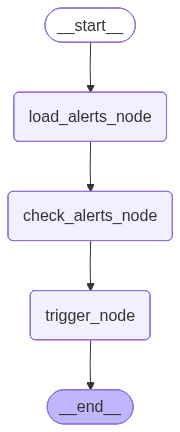

In [77]:
display(Image(alert_agent.get_graph().draw_mermaid_png()))

In [78]:
seed_test_alerts()

print(f"\n{'=' * 60}")
print("Running Alert Agent for: AAPL")
print("=" * 60)

alert_input: AlertAgentState = {
    "symbol": "AAPL",
    "user_id": 1,
    "current_price": 298.01,
    "rsi": 39.07,
    "price_change_pct": 48.85,
    "risk_score": 5.0,
    "active_alerts": None,
    "triggered_alerts": None,
    "skipped_alerts": None,
    "alerts_triggered": None,
    "errors": [],
}

result = alert_agent.invoke(alert_input)

print("\n── Final Output ─────────────────────────────")
print(f"Symbol:           {result['symbol']}")
print(f"Active alerts:    {len(result.get('active_alerts', []))}")
print(f"Triggered:        {result.get('alerts_triggered')}")
print(f"Errors:           {result.get('errors')}")
print("\nTriggered alerts:")
for alert in result.get("triggered_alerts", []):
    print(f"  [{alert['id']}] {alert['alert_type']} — {alert['reason']}")

✅ Seeded 6 test alerts for AAPL

Running Alert Agent for: AAPL
📋 Loading active alerts for AAPL (user: 1)...
✅ load_alerts_node → 6 active alerts for AAPL
   [8] price_above @ 250.0
   [9] price_above @ 350.0
   [10] price_below @ 300.0
   [11] rsi_above @ 70.0
   [12] rsi_below @ 45.0
   [13] change_above @ 20.0
🔍 Checking 6 alerts for AAPL...
   Price: $298.01 | RSI: 39.07 | Change: 48.85%
   🔔 TRIGGERED [8] price_above — Price $298.01 > threshold $250.0
   ⏭️  Skipped  [9] price_above @ 350.0
   🔔 TRIGGERED [10] price_below — Price $298.01 < threshold $300.0
   ⏭️  Skipped  [11] rsi_above @ 70.0
   🔔 TRIGGERED [12] rsi_below — RSI 39.07 < threshold 45.0 (oversold)
   🔔 TRIGGERED [13] change_above — 1Y change 48.85% > threshold 20.0%

✅ check_alerts_node → 4 triggered / 2 skipped
🔔 Triggering 4 alerts for AAPL...
   ✅ Alert [8] marked as triggered
      Type:   price_above
      Reason: Price $298.01 > threshold $250.0
   ✅ Alert [10] marked as triggered
      Type:   price_below
   

# Supervisor Agent


In [79]:
from typing import TypedDict, Optional, Literal


class SupervisorState(TypedDict):
    symbol: str
    user_id: Optional[int]
    mode: Literal["analyse", "report", "chat", "ingest"]

    question: Optional[str]
    file_path: Optional[str]

    data_output: Optional[dict]
    analysis_output: Optional[dict]
    rag_output: Optional[dict]
    report_output: Optional[dict]
    alert_output: Optional[dict]

    final_response: Optional[str]
    triggered_alerts: Optional[list[dict]]
    report_id: Optional[str]

    errors: Optional[list[str]]


In [80]:
analyse_state: SupervisorState = {
    "symbol": "AAPL",
    "user_id": 1,
    "mode": "analyse",
    "errors": [],
}

report_state: SupervisorState = {
    **analyse_state,
    "mode": "report",
}

chat_state: SupervisorState = {
    **analyse_state,
    "mode": "chat",
    "question": "What are the main risk factors for AAPL?",
}

ingest_state: SupervisorState = {
    **analyse_state,
    "mode": "ingest",
    "file_path": str(Path.cwd().parent / "aapl_annual_report.txt"),
}

In [81]:
def supervisor_route_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    mode = state["mode"]
    print(f"🎯 Supervisor routing → {symbol} | mode: {mode}")
    return {}

In [82]:
def run_data_agent_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])

    print(f"\n{'─' * 50}")
    print(f"🤖 Supervisor → Running Data Agent for {symbol}")
    print(f"{'─' * 50}")

    try:
        result = data_agent.invoke(
            {
                "symbol": symbol,
                "period": "1y",
                "retry_count": 0,
                "errors": [],
            }
        )

        print(
            f"✅ Data Agent complete → ${result.get('current_price')} | ready: {result.get('data_ready')}"
        )

        return {
            "data_output": result,
            "errors": errors + result.get("errors", []),
        }

    except Exception as e:
        error = f"run_data_agent_node error: {str(e)}"
        print(f"❌ {error}")
        return {"data_output": None, "errors": errors + [error]}

In [83]:
def run_analysis_agent_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    data_output = state.get("data_output", {})
    errors = state.get("errors", [])

    print(f"\n{'─' * 50}")
    print(f"🤖 Supervisor → Running Analysis Agent for {symbol}")
    print(f"{'─' * 50}")

    if not data_output:
        error = "No data_output available for analysis"
        print(f"❌ {error}")
        return {"analysis_output": None, "errors": errors + [error]}

    try:
        result = analysis_agent.invoke(
            {
                "symbol": data_output.get("symbol", symbol),
                "current_price": data_output.get("current_price"),
                "high_52w": data_output.get("high_52w"),
                "low_52w": data_output.get("low_52w"),
                "price_change_pct": data_output.get("price_change_pct"),
                "price_history": data_output.get("price_history"),
                "pe_ratio": data_output.get("pe_ratio"),
                "eps": data_output.get("eps"),
                "market_cap": data_output.get("market_cap"),
                "revenue": data_output.get("revenue"),
                "profit_margin": data_output.get("profit_margin"),
                "beta": data_output.get("beta"),
                "dividend_yield": data_output.get("dividend_yield"),
                "sector": data_output.get("sector"),
                "data_summary": data_output.get("summary"),
                "errors": [],
            }
        )

        print(
            f"✅ Analysis Agent complete → {result.get('recommendation', '').upper()} | risk: {result.get('risk_label')}"
        )

        return {
            "analysis_output": result,
            "errors": errors + result.get("errors", []),
        }

    except Exception as e:
        error = f"run_analysis_agent_node error: {str(e)}"
        print(f"❌ {error}")
        return {"analysis_output": None, "errors": errors + [error]}

In [84]:
def run_rag_agent_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    mode = state["mode"]
    question = state.get("question")
    file_path = state.get("file_path")
    errors = state.get("errors", [])

    print(f"\n{'─' * 50}")
    print(f"🤖 Supervisor → Running RAG Agent for {symbol} | mode: {mode}")
    print(f"{'─' * 50}")

    try:
        rag_mode = "ingest" if mode == "ingest" else "query"

        result = rag_agent.invoke(
            {
                "symbol": symbol,
                "mode": rag_mode,
                "file_path": file_path,
                "question": question,
                "errors": [],
            }
        )

        if rag_mode == "ingest":
            print(
                f"✅ RAG Agent complete → {result.get('chunks_stored')} chunks ingested"
            )
        else:
            print("✅ RAG Agent complete → answer generated")

        return {
            "rag_output": result,
            "errors": errors + result.get("errors", []),
        }

    except Exception as e:
        error = f"run_rag_agent_node error: {str(e)}"
        print(f"❌ {error}")
        return {"rag_output": None, "errors": errors + [error]}

In [85]:
def run_report_agent_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    data_output = state.get("data_output", {})
    analysis_output = state.get("analysis_output", {})
    rag_output = state.get("rag_output", {})
    errors = state.get("errors", [])

    print(f"\n{'─' * 50}")
    print(f"🤖 Supervisor → Running Report Agent for {symbol}")
    print(f"{'─' * 50}")

    rag_context = None
    if rag_output and rag_output.get("retrieved_docs"):
        rag_context = "\n\n".join(rag_output["retrieved_docs"][:3])

    try:
        result = report_agent.invoke(
            {
                "symbol": symbol,
                "current_price": data_output.get("current_price"),
                "price_change_pct": data_output.get("price_change_pct"),
                "market_cap": data_output.get("market_cap"),
                "pe_ratio": data_output.get("pe_ratio"),
                "eps": data_output.get("eps"),
                "revenue": data_output.get("revenue"),
                "profit_margin": data_output.get("profit_margin"),
                "beta": data_output.get("beta"),
                "sector": data_output.get("sector"),
                "industry": data_output.get("industry"),
                "data_summary": data_output.get("summary"),
                "sma_20": analysis_output.get("sma_20"),
                "sma_50": analysis_output.get("sma_50"),
                "rsi": analysis_output.get("rsi"),
                "macd": analysis_output.get("macd"),
                "volatility": analysis_output.get("volatility"),
                "golden_cross": analysis_output.get("golden_cross"),
                "pe_signal": analysis_output.get("pe_signal"),
                "margin_signal": analysis_output.get("margin_signal"),
                "momentum_signal": analysis_output.get("momentum_signal"),
                "risk_score": analysis_output.get("risk_score"),
                "risk_label": analysis_output.get("risk_label"),
                "recommendation": analysis_output.get("recommendation"),
                "reasoning": analysis_output.get("reasoning"),
                "rag_context": rag_context,
                "errors": [],
            }
        )

        print(f"✅ Report Agent complete → {result.get('report_id')}")

        return {
            "report_output": result,
            "report_id": result.get("report_id"),
            "errors": errors + result.get("errors", []),
        }

    except Exception as e:
        error = f"run_report_agent_node error: {str(e)}"
        print(f"❌ {error}")
        return {"report_output": None, "errors": errors + [error]}


In [86]:
def run_alert_agent_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    user_id = state.get("user_id")
    data_output = state.get("data_output", {})
    analysis_output = state.get("analysis_output", {})
    errors = state.get("errors", [])

    print(f"\n{'─' * 50}")
    print(f"🤖 Supervisor → Running Alert Agent for {symbol}")
    print(f"{'─' * 50}")

    try:
        result = alert_agent.invoke(
            {
                "symbol": symbol,
                "user_id": user_id,
                "current_price": data_output.get("current_price"),
                "rsi": analysis_output.get("rsi"),
                "price_change_pct": data_output.get("price_change_pct"),
                "risk_score": analysis_output.get("risk_score"),
                "errors": [],
            }
        )

        triggered = result.get("triggered_alerts", [])
        print(f"✅ Alert Agent complete → {len(triggered)} alerts triggered")

        return {
            "alert_output": result,
            "triggered_alerts": triggered,
            "errors": errors + result.get("errors", []),
        }

    except Exception as e:
        error = f"run_alert_agent_node error: {str(e)}"
        print(f"❌ {error}")
        return {"alert_output": None, "errors": errors + [error]}

In [88]:
def final_response_node(state: SupervisorState) -> dict:
    symbol = state["symbol"]
    mode = state["mode"]
    data_output = state.get("data_output", {})
    analysis_output = state.get("analysis_output", {})
    rag_output = state.get("rag_output", {})
    report_output = state.get("report_output", {})
    triggered_alerts = state.get("triggered_alerts", [])

    print(f"\n{'─' * 50}")
    print(f"📤 Supervisor → Building final response for {symbol}")
    print(f"{'─' * 50}")

    if mode == "ingest":
        chunks = state.get("rag_output", {}).get("chunks_stored", 0)
        response = (
            f"✅ Document successfully ingested for {symbol}. "
            f"{chunks} chunks added to knowledge base."
        )

    elif mode == "chat":
        response = rag_output.get("answer", "No answer generated.")

    elif mode == "analyse":
        response = f"""
        ANALYSIS SUMMARY — {symbol}
        {"─" * 40}
        Price:          ${data_output.get("current_price")}
        1Y Change:      {data_output.get("price_change_pct")}%
        RSI:            {analysis_output.get("rsi")}
        Risk:           {analysis_output.get("risk_score")}/10 ({analysis_output.get("risk_label")})
        Recommendation: {analysis_output.get("recommendation", "").upper()}

        {analysis_output.get("reasoning", "")}
        """
        if triggered_alerts:
            response += f"\n🔔 {len(triggered_alerts)} alert(s) triggered:\n"
            for alert in triggered_alerts:
                response += f"  • {alert['alert_type']} — {alert['reason']}\n"

    elif mode == "report":
        response = report_output.get("full_report", "Report generation failed.")
        if triggered_alerts:
            response += (
                f"\n🔔 {len(triggered_alerts)} alert(s) triggered during analysis."
            )

    else:
        response = "Unknown mode."

    print(f"✅ final_response_node → Response built for {symbol} ({mode} mode)")

    return {"final_response": response}

In [90]:
def route_by_query_mode(state: SupervisorState) -> str:
    mode = state["mode"]
    if mode in ("analyse", "report"):
        return "run_data_agent_node"
    elif mode == "chat":
        return "run_rag_agent_node"
    elif mode == "ingest":
        return "run_rag_agent_node"
    else:
        return "final_response_node"


def after_data_agent(state: SupervisorState) -> str:
    mode = state["mode"]
    if mode in ("analyse", "report"):
        return "run_analysis_agent_node"
    return "final_response_node"


def after_analysis_agent(state: SupervisorState) -> str:
    mode = state["mode"]
    if mode == "report":
        return "run_rag_agent_node"
    return "run_alert_agent_node"


def after_rag_agent(state: SupervisorState) -> str:
    mode = state["mode"]
    if mode == "report":
        return "run_report_agent_node"
    elif mode in ("chat", "ingest"):
        return "final_response_node"
    return "final_response_node"

In [91]:
def build_supervisor():
    graph = StateGraph(SupervisorState)

    graph.add_node("supervisor_route_node", supervisor_route_node)
    graph.add_node("run_data_agent_node", run_data_agent_node)
    graph.add_node("run_analysis_agent_node", run_analysis_agent_node)
    graph.add_node("run_rag_agent_node", run_rag_agent_node)
    graph.add_node("run_report_agent_node", run_report_agent_node)
    graph.add_node("run_alert_agent_node", run_alert_agent_node)
    graph.add_node("final_response_node", final_response_node)

    graph.set_entry_point("supervisor_route_node")

    graph.add_conditional_edges(
        "supervisor_route_node",
        route_by_query_mode,
        {
            "run_data_agent_node": "run_data_agent_node",
            "run_rag_agent_node": "run_rag_agent_node",
            "final_response_node": "final_response_node",
        },
    )

    graph.add_conditional_edges(
        "run_data_agent_node",
        after_data_agent,
        {
            "run_analysis_agent_node": "run_analysis_agent_node",
            "final_response_node": "final_response_node",
        },
    )

    graph.add_conditional_edges(
        "run_analysis_agent_node",
        after_analysis_agent,
        {
            "run_rag_agent_node": "run_rag_agent_node",
            "run_alert_agent_node": "run_alert_agent_node",
        },
    )

    graph.add_conditional_edges(
        "run_rag_agent_node",
        after_rag_agent,
        {
            "run_report_agent_node": "run_report_agent_node",
            "final_response_node": "final_response_node",
        },
    )

    graph.add_edge("run_report_agent_node", "run_alert_agent_node")

    graph.add_edge("run_alert_agent_node", "final_response_node")

    graph.add_edge("final_response_node", END)

    return graph.compile()


supervisor = build_supervisor()

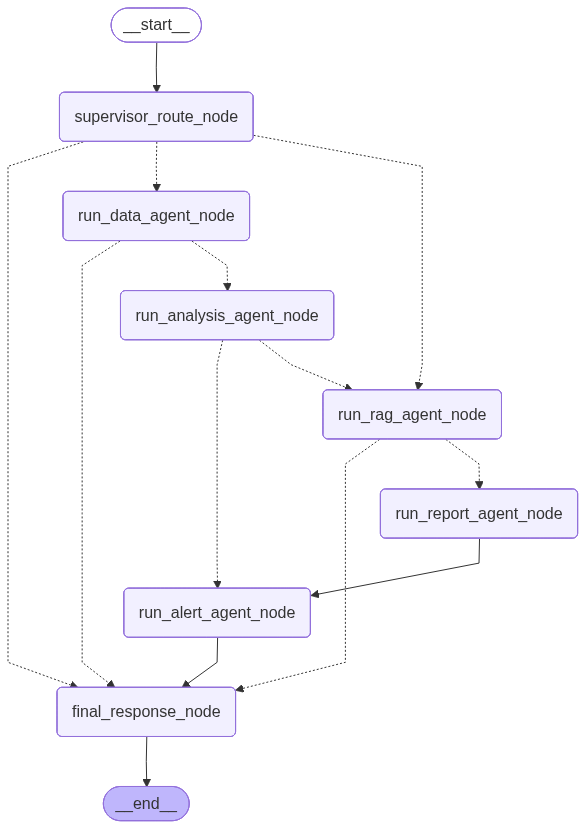

In [92]:
display(Image(supervisor.get_graph().draw_mermaid_png()))

In [93]:
print("=" * 60)
print("TEST 1 — Analyse Mode")
print("=" * 60)

result = supervisor.invoke(
    {
        "symbol": "AAPL",
        "user_id": 1,
        "mode": "analyse",
        "errors": [],
    }
)

print("\n── Final Response ───────────────────────────")
print(result["final_response"])
print(f"\nErrors: {result['errors']}")

TEST 1 — Analyse Mode
🎯 Supervisor routing → AAPL | mode: analyse

──────────────────────────────────────────────────
🤖 Supervisor → Running Data Agent for AAPL
──────────────────────────────────────────────────
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
✅ fetch_fundamentals_node → AAPL
   Market Cap:    $4,376,979,046,000
   P/E Ratio:     36.12
   EPS:           8.25
   Profit Margin: 0.272
   Sector:        TECHNOLOGY
   Industry:      CONSUMER ELECTRONICS
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ✅
   Retry count:        0/2
✅ validate_node → All data valid, proceeding
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL's current market capitalization stands at approximately $4.38 trillion, with a price-to-earnings ratio of 36

In [95]:
print("=" * 60)
print("TEST 2 — Chat Mode")
print("=" * 60)

result = supervisor.invoke(
    {
        "symbol": "AAPL",
        "user_id": 1,
        "mode": "chat",
        "question": "What are Apple's main risk factors?",
        "errors": [],
    }
)

print("\n── Final Response ───────────────────────────")
print(result["final_response"])
print(f"\nErrors: {result['errors']}")

TEST 2 — Chat Mode
🎯 Supervisor routing → AAPL | mode: chat

──────────────────────────────────────────────────
🤖 Supervisor → Running RAG Agent for AAPL | mode: chat
──────────────────────────────────────────────────
🔀 route_node → AAPL | mode: query
🔍 Retrieving docs for AAPL: 'What are Apple's main risk factors?'
   Score: 0.8961 | APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Condit...
   Score: 0.8961 | APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Condit...
   Score: 0.7763 | 2. Supply Chain Concentration
Apple relies heavily on suppliers in Asia, particu...
   Score: 0.7763 | 2. Supply Chain Concentration
Apple relies heavily on suppliers in Asia, particu...
✅ retrieve_node → 4 relevant chunks for AAPL
💬 Generating answer for AAPL: 'What are Apple's main risk factors?'
✅ answer_node → Answer generated for AAPL

── Answer ───────────────────────────────
According to the provided context from "aapl_annual_report.txt, Page 0",

In [96]:
print("=" * 60)
print("TEST 3 — Ingest Mode")
print("=" * 60)

result = supervisor.invoke(
    {
        "symbol": "MSFT",
        "user_id": 1,
        "mode": "ingest",
        "file_path": str(Path.cwd() / "aapl_annual_report.txt"),
        "errors": [],
    }
)

print("\n── Final Response ───────────────────────────")
print(result["final_response"])
print(f"\nErrors: {result['errors']}")

TEST 3 — Ingest Mode
🎯 Supervisor routing → MSFT | mode: ingest

──────────────────────────────────────────────────
🤖 Supervisor → Running RAG Agent for MSFT | mode: ingest
──────────────────────────────────────────────────
🔀 route_node → MSFT | mode: ingest
📄 Ingesting document for MSFT: d:\ai-learning\finsight-ai\agent\notebooks\aapl_annual_report.txt
   Loaded 1 page(s)
   Split into 4 chunks
✅ ingest_node → 4 chunks ready for MSFT
⏳ Embedding 4 chunks for MSFT...
✅ embed_node → 4 chunks upserted for MSFT
✅ RAG Agent complete → 4 chunks ingested

──────────────────────────────────────────────────
📤 Supervisor → Building final response for MSFT
──────────────────────────────────────────────────
✅ final_response_node → Response built for MSFT (ingest mode)

── Final Response ───────────────────────────
✅ Document successfully ingested for MSFT. 4 chunks added to knowledge base.

Errors: []


In [97]:
print("=" * 60)
print("TEST 4 — Report Mode")
print("=" * 60)

result = supervisor.invoke(
    {
        "symbol": "AAPL",
        "user_id": 1,
        "mode": "report",
        "question": "What are the main risk factors?",
        "errors": [],
    }
)

print("\n── Final Response ───────────────────────────")
print(result["final_response"])
print(f"\nReport ID: {result.get('report_id')}")
print(f"Triggered: {result.get('triggered_alerts')}")
print(f"Errors:    {result['errors']}")

TEST 4 — Report Mode
🎯 Supervisor routing → AAPL | mode: report

──────────────────────────────────────────────────
🤖 Supervisor → Running Data Agent for AAPL
──────────────────────────────────────────────────
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
✅ fetch_fundamentals_node → AAPL
   Market Cap:    $4,376,979,046,000
   P/E Ratio:     36.12
   EPS:           8.25
   Profit Margin: 0.272
   Sector:        TECHNOLOGY
   Industry:      CONSUMER ELECTRONICS
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ✅
   Retry count:        0/2
✅ validate_node → All data valid, proceeding
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL's current market capitalization stands at approximately $4.38 trillion, with a price-to-earnings ratio of 36.1